# View offline **ranking** eval (read-only)

Loads CSVs from `recs_job_eval_ranking.py` (frozen pools → rerank + full-catalog `popularity_train` baseline). Does **not** re-score two-tower retrieval.

**Gating comparison (ranking stage, `k_final=10`):** best **ranker** on frozen two-tower pools vs full-catalog **`popularity_train`**. Retrieval-only tables under `runs/latest/` answer a different question — use this notebook for the ranking-stage gate.

**Interview framing:** On a frozen 12.5k val cohort, two-tower retrieval pools reranked with a tuned log-pop blend beat the full-catalog popularity baseline on NDCG@10 and Hit@10, including Slice A multi-positive users (primary ranking slice).

**Prerequisite:**

1. Retrieval pools: `python scripts/recs_job_eval_offline.py configs/recs_job_eval_offline.json --examples-parquet artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet`
2. Ranking eval: `python scripts/recs_job_eval_ranking.py configs/recs_job_eval_ranking.json`

Contract: [`docs/recommendation_evaluation_overview.md`](../../docs/recommendation_evaluation_overview.md)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

# "latest_ranking" (default) or a named folder under runs/
EVAL_RUN = "latest_ranking"

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
RUNS_ROOT = REPO_ROOT / "artifacts/recs/offline_eval/runs"
EVAL_DIR = RUNS_ROOT / EVAL_RUN

if not EVAL_DIR.is_dir():
    raise FileNotFoundError(
        f"Ranking eval dir not found: {EVAL_DIR}\n"
        "Run: python scripts/recs_job_eval_ranking.py configs/recs_job_eval_ranking.json"
    )

PATHS = {
    "ranking_overall": EVAL_DIR / "eval_ranking_overall.csv",
    "ranking_by_slice": EVAL_DIR / "eval_ranking_by_slice.csv",
    "ranking_by_support": EVAL_DIR / "eval_ranking_by_support_bucket.csv",
    "ranking_by_pop_decile": EVAL_DIR / "eval_ranking_by_pop_decile.csv",
    "ranking_pop_delta": EVAL_DIR / "eval_ranking_pop_delta_vs_popularity.csv",
    "ranking_personalization": EVAL_DIR / "eval_ranking_personalization.csv",
    "run_meta": EVAL_DIR / "eval_ranking_run_meta.json",
}
print(f"EVAL_DIR={EVAL_DIR}")

EVAL_DIR=/home/ryanr/workspace/steam_recommendations/artifacts/recs/offline_eval/runs/latest_ranking


In [2]:
POP_BASELINE = "popularity_train"
DELTA_METRICS = ("Hit@K", "NDCG@K", "MAP@K", "MRR")


def _load_csv(key: str) -> pd.DataFrame | None:
    path = PATHS[key]
    if not path.is_file():
        print(f"skip {key}: missing {path.name}")
        return None
    return pd.read_csv(path)


def _delta_vs_pop(df: pd.DataFrame, *, group_cols: list[str] | None = None) -> pd.DataFrame | None:
    """Non-baseline methods with metric deltas vs popularity_train."""
    if df is None or POP_BASELINE not in set(df["method"]):
        return None
    metrics = [m for m in DELTA_METRICS if m in df.columns]
    if not metrics:
        return None

    if group_cols:
        rows: list[dict[str, object]] = []
        for keys, grp in df.groupby(group_cols, sort=False):
            if POP_BASELINE not in set(grp["method"]):
                continue
            pop = grp.loc[grp["method"] == POP_BASELINE, metrics].iloc[0]
            key_tuple = keys if isinstance(keys, tuple) else (keys,)
            for _, row in grp.loc[grp["method"] != POP_BASELINE].iterrows():
                out: dict[str, object] = dict(zip(group_cols, key_tuple))
                out["method"] = row["method"]
                for m in metrics:
                    out[m] = row[m]
                    out[f"{m}_delta"] = row[m] - pop[m]
                rows.append(out)
        if not rows:
            return None
        return pd.DataFrame(rows).sort_values([*group_cols, "NDCG@K"], ascending=[True] * len(group_cols) + [False])

    pop = df.loc[df["method"] == POP_BASELINE, metrics].iloc[0]
    out = df.loc[df["method"] != POP_BASELINE, ["method", *metrics]].copy()
    for m in metrics:
        out[f"{m}_delta"] = out[m] - pop[m]
    return out.sort_values("NDCG@K", ascending=False)


rank_overall = _load_csv("ranking_overall")
rank_slice = _load_csv("ranking_by_slice")
rank_person = _load_csv("ranking_personalization")

run_meta = None
if PATHS["run_meta"].is_file():
    run_meta = json.loads(PATHS["run_meta"].read_text(encoding="utf-8"))
    print("pool_methods:", run_meta.get("pool_methods"))
    print("ranker_methods:", run_meta.get("ranker_methods"))
    print("catalog_methods:", run_meta.get("catalog_methods"))
    print("examples_parquet:", run_meta.get("examples_parquet"))
    print("n_examples_ranked:", run_meta.get("n_examples_ranked"))
    print("pools_jsonl:", run_meta.get("pools_jsonl"))
    print(
        f"k_final={run_meta.get('k_final')} k_retrieval={run_meta.get('k_retrieval')} "
        f"k_personalization={run_meta.get('k_personalization')}"
    )
else:
    print("no eval_ranking_run_meta.json")

pool_methods: ['two_tower_v1']
ranker_methods: ['two_tower_v1_heuristic_logpop_blend']
catalog_methods: ['popularity_train']
examples_parquet: /home/ryanr/workspace/steam_recommendations/artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet
n_examples_ranked: 12500
pools_jsonl: /home/ryanr/workspace/steam_recommendations/artifacts/recs/offline_eval/runs/latest/eval_offline_examples.jsonl
k_final=10 k_retrieval=100 k_personalization=10


In [3]:
display(Markdown("### Ranking overall (sorted by NDCG@K)"))
display(
    Markdown(
        "Methods: **catalog** (`popularity_train` = global pop scores) · "
        "**pool** (`two_tower_v1` = frozen pool order) · "
        "**ranker** (`*_heuristic_*` = rerank within pool)"
    )
)
if rank_overall is not None:
    display(rank_overall.sort_values("NDCG@K", ascending=False))

display(Markdown("### Personalization (standalone, same as appended cols on overall)"))
if rank_person is not None:
    display(rank_person.sort_values("PersonalizationGapVsPopularity@10", ascending=False))

### Ranking overall (sorted by NDCG@K)

Methods: **catalog** (`popularity_train` = global pop scores) · **pool** (`two_tower_v1` = frozen pool order) · **ranker** (`*_heuristic_*` = rerank within pool)

,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,two_tower_v1_heuristic_logpop_blend,0.19328,0.019560,0.184095,0.064321,0.092892,0.067059,0.51224,0.498310,0.204632,0.501587,6.272161,0.720097
1,popularity_train,0.15112,0.015184,0.146796,0.050594,0.073109,0.052221,0.76280,0.752102,0.212335,0.034921,5.317471,0.000000
2,two_tower_v1,0.04680,0.004728,0.043740,0.010325,0.018161,0.011008,0.51224,0.498310,0.261639,0.987302,12.167556,0.995623


### Personalization (standalone, same as appended cols on overall)

,method,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
1,two_tower_v1,0.261639,0.987302,12.167556,0.995623
2,two_tower_v1_heuristic_logpop_blend,0.204632,0.501587,6.272161,0.720097
0,popularity_train,0.212335,0.034921,5.317471,0.000000


In [4]:
display(Markdown("### By slice"))
if rank_slice is not None:
    display(rank_slice.sort_values(["slice_name", "NDCG@K"], ascending=[True, False]))

display(Markdown("### By support bucket"))
rank_support = _load_csv("ranking_by_support")
if rank_support is not None:
    display(rank_support.sort_values(["train_support_bucket", "NDCG@K"], ascending=[True, False]))

### By slice

,slice_name,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,slice_a_multi_target,two_tower_v1_heuristic_logpop_blend,0.271724,0.031172,0.113367,0.034181,0.068322,0.081396,0.773793,0.533618,0.203806,0.412698,6.504750,0.793487
1,slice_a_multi_target,popularity_train,0.128276,0.014069,0.053728,0.019418,0.035444,0.047469,0.892414,0.707962,0.212240,0.034921,5.312688,0.000000
2,slice_a_multi_target,two_tower_v1,0.091034,0.009931,0.038280,0.009408,0.020537,0.021192,0.773793,0.533618,0.256915,0.933333,12.163190,0.997354
3,slice_b_single_target,two_tower_v1_heuristic_logpop_blend,0.188450,0.018845,0.188450,0.066176,0.094404,0.066176,0.496136,0.496136,0.204683,0.501587,6.257840,0.715579
4,slice_b_single_target,popularity_train,0.152527,0.015253,0.152527,0.052514,0.075428,0.052514,0.754820,0.754820,0.212341,0.034921,5.317765,0.000000
5,slice_b_single_target,two_tower_v1,0.044076,0.004408,0.044076,0.010381,0.018015,0.010381,0.496136,0.496136,0.261930,0.987302,12.167824,0.995516


### By support bucket

,train_support_bucket,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,0,two_tower_v1_heuristic_logpop_blend,0.211200,0.021120,0.211040,0.078975,0.109642,0.079055,0.504000,0.504000,0.204387,0.463492,6.162312,0.685295
1,0,popularity_train,0.174720,0.017472,0.174720,0.061863,0.087912,0.061863,0.760960,0.760960,0.212432,0.034921,5.319178,0.000000
2,0,two_tower_v1,0.049920,0.004992,0.049760,0.011584,0.020272,0.011638,0.504000,0.504000,0.262590,0.965079,12.187545,0.994675
3,1,two_tower_v1_heuristic_logpop_blend,0.208960,0.020896,0.208960,0.074154,0.105206,0.074154,0.511680,0.511680,0.205091,0.466667,6.216828,0.703931
4,1,popularity_train,0.181120,0.018112,0.181120,0.062714,0.089706,0.062714,0.786560,0.786560,0.212320,0.034921,5.319652,0.000000
5,1,two_tower_v1,0.044800,0.004480,0.044800,0.010378,0.018183,0.010378,0.511680,0.511680,0.263031,0.980952,12.161975,0.995439
6,2-3,two_tower_v1_heuristic_logpop_blend,0.176128,0.017613,0.176128,0.060125,0.086892,0.060125,0.487953,0.487699,0.204689,0.473016,6.294136,0.726390
7,2-3,popularity_train,0.136804,0.013680,0.136666,0.045143,0.066066,0.045163,0.750762,0.750524,0.212267,0.034921,5.316660,0.000000
8,2-3,two_tower_v1,0.039878,0.003988,0.039740,0.009446,0.016265,0.009492,0.487953,0.487699,0.261712,0.974603,12.159349,0.995639
9,4-7,two_tower_v1_heuristic_logpop_blend,0.176961,0.018795,0.133646,0.041064,0.066684,0.053940,0.555892,0.490258,0.204301,0.457143,6.437694,0.771843


In [5]:
display(Markdown("### Headline vs `popularity_train` (ranker methods only)"))
headline = _delta_vs_pop(rank_overall)
if headline is not None:
    display(headline)
else:
    print(f"skip headline: no {POP_BASELINE!r} row in ranking_overall")

display(Markdown("### Headline by slice (ranker vs popularity delta)"))
slice_headline = _delta_vs_pop(rank_slice, group_cols=["slice_name"])
if slice_headline is not None:
    display(slice_headline)
else:
    print("skip slice headline")

if rank_overall is not None:
    cols = [
        "method",
        "Hit@K",
        "NDCG@K",
        "MRR",
        "OracleNDCG@K",
        "PersonalizationGapVsPopularity@10",
    ]
    cols = [c for c in cols if c in rank_overall.columns]
    display(Markdown("### Full methods (relevance + personalization gap)"))
    display(rank_overall[cols].sort_values("NDCG@K", ascending=False))

### Headline vs `popularity_train` (ranker methods only)

,method,Hit@K,NDCG@K,MAP@K,MRR,Hit@K_delta,NDCG@K_delta,MAP@K_delta,MRR_delta
0,two_tower_v1_heuristic_logpop_blend,0.19328,0.092892,0.064321,0.067059,0.04216,0.019782,0.013727,0.014838
2,two_tower_v1,0.04680,0.018161,0.010325,0.011008,-0.10432,-0.054948,-0.040269,-0.041213


### Headline by slice (ranker vs popularity delta)

,slice_name,method,Hit@K,Hit@K_delta,NDCG@K,NDCG@K_delta,MAP@K,MAP@K_delta,MRR,MRR_delta
0,slice_a_multi_target,two_tower_v1_heuristic_logpop_blend,0.271724,0.143448,0.068322,0.032878,0.034181,0.014764,0.081396,0.033928
1,slice_a_multi_target,two_tower_v1,0.091034,-0.037241,0.020537,-0.014906,0.009408,-0.010010,0.021192,-0.026277
2,slice_b_single_target,two_tower_v1_heuristic_logpop_blend,0.188450,0.035924,0.094404,0.018976,0.066176,0.013663,0.066176,0.013663
3,slice_b_single_target,two_tower_v1,0.044076,-0.108450,0.018015,-0.057414,0.010381,-0.042132,0.010381,-0.042132


### Full methods (relevance + personalization gap)

,method,Hit@K,NDCG@K,MRR,OracleNDCG@K,PersonalizationGapVsPopularity@10
0,two_tower_v1_heuristic_logpop_blend,0.19328,0.092892,0.067059,0.498310,0.720097
1,popularity_train,0.15112,0.073109,0.052221,0.752102,0.000000
2,two_tower_v1,0.04680,0.018161,0.011008,0.498310,0.995623


In [6]:
display(Markdown("### By target popularity decile"))
rank_pop_decile = _load_csv("ranking_by_pop_decile")
if rank_pop_decile is not None:
    display(rank_pop_decile.sort_values(["pos_pop_decile", "NDCG@K"], ascending=[True, False]))

display(Markdown("### Delta vs popularity by decile (precomputed)"))
rank_pop_delta = _load_csv("ranking_pop_delta")
if rank_pop_delta is not None:
    delta_cols = [
        c
        for c in rank_pop_delta.columns
        if c.endswith("_delta_vs_pop") and c.replace("_delta_vs_pop", "") in DELTA_METRICS
    ]
    show_cols = ["pos_pop_decile", "method", *DELTA_METRICS, *delta_cols]
    show_cols = [c for c in show_cols if c in rank_pop_delta.columns]
    display(rank_pop_delta[show_cols].sort_values(["pos_pop_decile", "NDCG@K"], ascending=[True, False]))

### By target popularity decile

,pos_pop_decile,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,OracleHit@K,OracleNDCG@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
1,D1,two_tower_v1,0.101992,0.010199,0.099469,0.027076,0.043887,0.027899,0.519522,0.512541,0.256939,0.942857,12.170429,0.996755
2,D1,two_tower_v1_heuristic_logpop_blend,0.002390,0.000239,0.002390,0.000279,0.000733,0.000279,0.519522,0.512541,0.203366,0.460317,6.398848,0.760198
0,D1,popularity_train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000797,0.000374,0.212278,0.034921,5.314266,0.000000
3,D10,popularity_train,1.000000,0.100357,0.997024,0.479675,0.605472,0.482485,1.000000,1.000000,0.212579,0.034921,5.321464,0.000000
5,D10,two_tower_v1_heuristic_logpop_blend,0.550000,0.055089,0.547917,0.276713,0.342505,0.278561,0.563393,0.561111,0.204580,0.422222,6.065537,0.647421
4,D10,two_tower_v1,0.026786,0.002679,0.026339,0.003877,0.008860,0.003927,0.563393,0.561111,0.264784,0.936508,12.195263,0.992603
7,D2,two_tower_v1,0.066667,0.006667,0.062349,0.015125,0.026289,0.016279,0.530120,0.519149,0.260038,0.946032,12.161091,0.995588
8,D2,two_tower_v1_heuristic_logpop_blend,0.015261,0.001526,0.013454,0.003533,0.005955,0.004147,0.530120,0.519149,0.204438,0.434921,6.344277,0.743211
6,D2,popularity_train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027309,0.014331,0.212295,0.034921,5.315455,0.000000
10,D3,two_tower_v1,0.042636,0.004419,0.039729,0.010470,0.017482,0.011461,0.506202,0.490053,0.261847,0.952381,12.207231,0.995810


### Delta vs popularity by decile (precomputed)

,pos_pop_decile,method,Hit@K,NDCG@K,MAP@K,MRR,Hit@K_delta_vs_pop,MAP@K_delta_vs_pop,NDCG@K_delta_vs_pop,MRR_delta_vs_pop
1,D1,two_tower_v1,0.101992,0.043887,0.027076,0.027899,0.101992,0.027076,0.043887,0.027899
2,D1,two_tower_v1_heuristic_logpop_blend,0.002390,0.000733,0.000279,0.000279,0.002390,0.000279,0.000733,0.000279
0,D1,popularity_train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,D10,popularity_train,1.000000,0.605472,0.479675,0.482485,0.000000,0.000000,0.000000,0.000000
5,D10,two_tower_v1_heuristic_logpop_blend,0.550000,0.342505,0.276713,0.278561,-0.450000,-0.202962,-0.262967,-0.203924
4,D10,two_tower_v1,0.026786,0.008860,0.003877,0.003927,-0.973214,-0.475798,-0.596612,-0.478558
7,D2,two_tower_v1,0.066667,0.026289,0.015125,0.016279,0.066667,0.015125,0.026289,0.016279
8,D2,two_tower_v1_heuristic_logpop_blend,0.015261,0.005955,0.003533,0.004147,0.015261,0.003533,0.005955,0.004147
6,D2,popularity_train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,D3,two_tower_v1,0.042636,0.017482,0.010470,0.011461,0.042636,0.010470,0.017482,0.011461


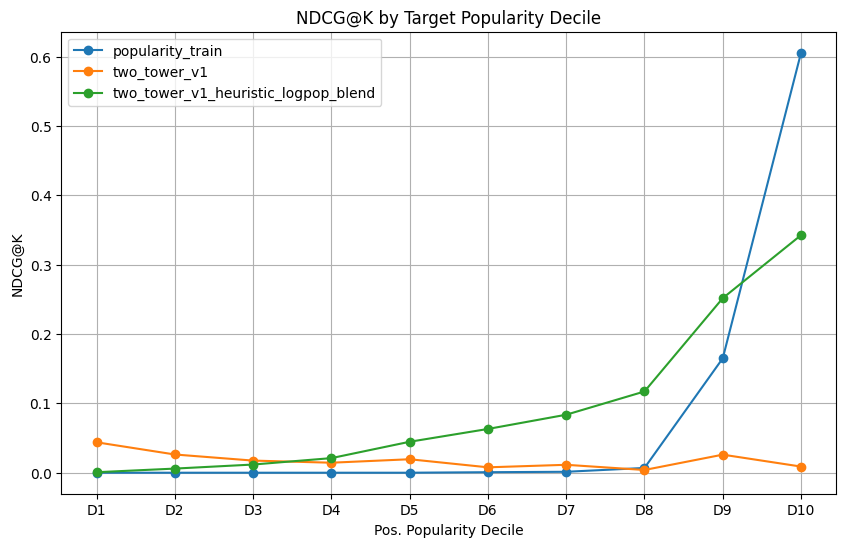

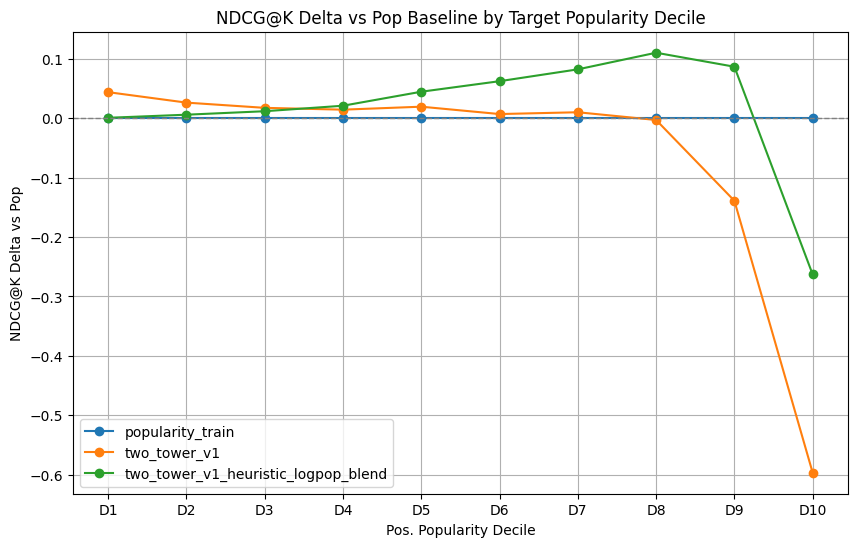

In [7]:
import matplotlib.pyplot as plt

# Helper to sort deciles so D10 always at end, rest by natural order
def _decile_sort_key(decile_val):
    # Assumes D1 .. D10 format (string or int); D10 as last
    if isinstance(decile_val, str) and decile_val.strip().upper() == "D10":
        return (99,)
    try:
        # If int-like or "D1", "D2" ... pick int part for sort
        sval = str(decile_val).strip().upper()
        if sval.startswith("D") and sval[1:].isdigit():
            return (int(sval[1:]),)
        return (int(sval),)
    except Exception:
        return (0,)

# Plot 1: NDCG@K by target popularity decile, for each method
if rank_pop_decile is not None:
    plt.figure(figsize=(10, 6))
    for method, df_group in rank_pop_decile.groupby("method"):
        # Sort deciles with D10 at end
        df_group_sorted = df_group.copy()
        df_group_sorted.loc[:, "decile_sort_order"] = df_group_sorted["pos_pop_decile"].map(_decile_sort_key)
        df_group_sorted = df_group_sorted.sort_values("decile_sort_order")
        plt.plot(
            df_group_sorted["pos_pop_decile"],
            df_group_sorted["NDCG@K"],
            marker="o",
            label=method,
        )
    plt.title("NDCG@K by Target Popularity Decile")
    plt.xlabel("Pos. Popularity Decile")
    plt.ylabel("NDCG@K")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot 2: Delta NDCG@K vs pop by decile per method (if available)
if rank_pop_delta is not None:
    ndcg_delta_cols = [c for c in rank_pop_delta.columns if c.startswith("NDCG@K_delta_vs_pop")]
    methods = rank_pop_delta["method"].unique()
    plt.figure(figsize=(10, 6))
    for method in methods:
        df_method = rank_pop_delta[rank_pop_delta["method"] == method]
        # Sort deciles with D10 at end
        df_method_sorted = df_method.copy()
        df_method_sorted.loc[:, "decile_sort_order"] = df_method_sorted["pos_pop_decile"].map(_decile_sort_key)
        df_method_sorted = df_method_sorted.sort_values("decile_sort_order")
        plt.plot(
            df_method_sorted["pos_pop_decile"],
            df_method_sorted["NDCG@K_delta_vs_pop"] if "NDCG@K_delta_vs_pop" in df_method_sorted else df_method_sorted[ndcg_delta_cols[0]],
            marker="o",
            label=method,
        )
    plt.title("NDCG@K Delta vs Pop Baseline by Target Popularity Decile")
    plt.xlabel("Pos. Popularity Decile")
    plt.ylabel("NDCG@K Delta vs Pop")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.legend()
    plt.grid(True)
    plt.show()